# CNN Architecture Comparison Exercises


In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.applications import ResNet50, DenseNet121
from tensorflow.keras.utils import to_categorical
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report
import time

tf.random.set_seed(42)
np.random.seed(42)

print("TensorFlow version:", tf.__version__)
print("Keras version:", keras.__version__)
print("GPUs:", len(tf.config.list_physical_devices('GPU')))

TensorFlow version: 2.19.0
Keras version: 3.10.0
GPUs: 1


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 15s 0us/step
Training data shape: (50000, 32, 32, 3)
Training labels shape: (50000, 10)
Test data shape: (10000, 32, 32, 3)
Test labels shape: (10000, 10)


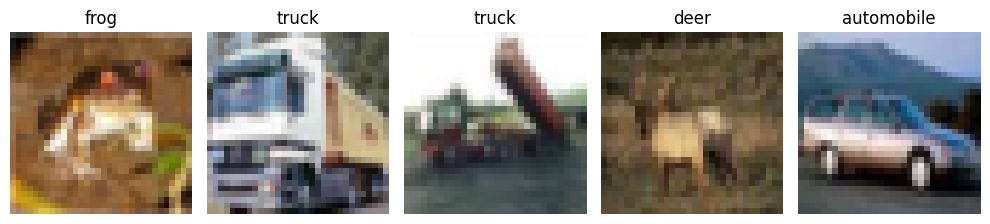

In [2]:
# Load CIFAR-10 dataset
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

# Normalize pixel values to [0, 1]
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Convert labels to categorical
num_classes = 10
y_train_cat = to_categorical(y_train, num_classes)
y_test_cat = to_categorical(y_test, num_classes)

# CIFAR-10 class names
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

print("Training data shape:", x_train.shape)
print("Training labels shape:", y_train_cat.shape)
print("Test data shape:", x_test.shape)
print("Test labels shape:", y_test_cat.shape)

# Visualize some samples
plt.figure(figsize=(10, 4))
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis('off')
plt.tight_layout()
plt.show()


In [3]:
def create_custom_cnn():
    model = models.Sequential([
        # First Conv Block
        layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),
        # Second Conv Block
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),
        # Third Conv Block
        layers.Conv2D(128, (3, 3), activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.25),
        # Fourth Conv Block
        layers.Conv2D(128, (3, 3), activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.25),
        # Classifier
        layers.GlobalAveragePooling2D(),
        layers.Dense(512, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

custom_cnn = create_custom_cnn()
custom_cnn.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Print model summary and params
custom_cnn.summary()
print(f"\nTotal trainable parameters: {custom_cnn.count_params():,}")

# Callbacks
early_stopping = callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=5,
    restore_best_weights=True,
    verbose=1
)
reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    min_lr=0.0001,
    verbose=1
)

# Train
start_time = time.time()
history_custom = custom_cnn.fit(
    x_train, y_train_cat,
    batch_size=128,
    epochs=20,
    validation_data=(x_test, y_test_cat),
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)
custom_train_time = time.time() - start_time

# Evaluate
custom_loss, custom_accuracy = custom_cnn.evaluate(x_test, y_test_cat, verbose=0)
print(f"\nCustom CNN Results:")
print(f"Test Accuracy: {custom_accuracy:.4f}")
print(f"Test Loss: {custom_loss:.4f}")
print(f"Training Time: {custom_train_time:.2f} seconds")
print(f"Early stopping triggered at epoch: {early_stopping.stopped_epoch + 1 if early_stopping.stopped_epoch > 0 else 'Not triggered'}")


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 30, 30, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 13, 13, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 4, 4, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 2, 2, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 2, 2, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │        66,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 313,418 (1.20 MB)

 Trainable params: 312,714 (1.19 MB)

 Non-trainable params: 704 (2.75 KB)


Total trainable parameters: 313,418
Epoch 1/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 25s 34ms/step - accuracy: 0.3791 - loss: 1.6983 - val_accuracy: 0.2328 - val_loss: 2.8827 - learning_rate: 0.0010
Epoch 2/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.5837 - loss: 1.1716 - val_accuracy: 0.5383 - val_loss: 1.4187 - learning_rate: 0.0010
Epoch 3/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.6403 - loss: 1.0224 - val_accuracy: 0.6078 - val_loss: 1.1664 - learning_rate: 0.0010
Epoch 4/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.6698 - loss: 0.9343 - val_accuracy: 0.6902 - val_loss: 0.8951 - learning_rate: 0.0010
Epoch 5/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.6991 - loss: 0.8683 - val_accuracy: 0.7056 - val_loss: 0.8489 - learning_rate: 0.0010
Epoch 6/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.7145 - loss: 0.8201 - val_accuracy: 0.6557 - val_loss: 1.0389 - learning_rate: 0.0010
Epoch 7/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/st

In [4]:
def create_resnet50_model():
    base_model = ResNet50(
        weights='imagenet',
        include_top=False,
        input_shape=(32, 32, 3)
    )
    base_model.trainable = False
    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model, base_model

resnet50_model, resnet50_base = create_resnet50_model()
resnet50_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

print("ResNet50 Model Summary (Frozen Base):")
resnet50_model.summary()
print(f"Total trainable parameters (frozen): {resnet50_model.count_params():,}")

start_time = time.time()
history_resnet_frozen = resnet50_model.fit(
    x_train, y_train_cat,
    batch_size=128,
    epochs=10,
    validation_data=(x_test, y_test_cat),
    callbacks=[callbacks.EarlyStopping(patience=3, restore_best_weights=True)],
    verbose=1
)

# Fine-tuning
resnet50_base.trainable = True
fine_tune_at = len(resnet50_base.layers) - 20
for layer in resnet50_base.layers[:fine_tune_at]:
    layer.trainable = False
resnet50_model.compile(optimizer=keras.optimizers.Adam(1e-5), loss='categorical_crossentropy', metrics=['accuracy'])

print(f"\nFine-tuning from layer {fine_tune_at} onwards...")
print(f"Total trainable parameters (fine-tuning): {resnet50_model.count_params():,}")

history_resnet_finetuned = resnet50_model.fit(
    x_train, y_train_cat,
    batch_size=128,
    epochs=10,
    validation_data=(x_test, y_test_cat),
    callbacks=[callbacks.EarlyStopping(patience=3, restore_best_weights=True)],
    verbose=1
)
resnet50_train_time = time.time() - start_time

resnet50_loss, resnet50_accuracy = resnet50_model.evaluate(x_test, y_test_cat, verbose=0)
print(f"\nResNet50 Results:")
print(f"Test Accuracy: {resnet50_accuracy:.4f}")
print(f"Test Loss: {resnet50_loss:.4f}")
print(f"Training Time: {resnet50_train_time:.2f} seconds")


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step
ResNet50 Model Summary (Frozen Base):


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 1, 1, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,851,274 (90.99 MB)

 Trainable params: 263,562 (1.01 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

Total trainable parameters (frozen): 23,851,274
Epoch 1/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 30s 46ms/step - accuracy: 0.1219 - loss: 2.3954 - val_accuracy: 0.1693 - val_loss: 2.1960
Epoch 2/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.1458 - loss: 2.2145 - val_accuracy: 0.1958 - val_loss: 2.1284
Epoch 3/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.1544 - loss: 2.1908 - val_accuracy: 0.2140 - val_loss: 2.1017
Epoch 4/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.1630 - loss: 2.1730 - val_accuracy: 0.2336 - val_loss: 2.1082
Epoch 5/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.1717 - loss: 2.1581 - val_accuracy: 0.2572 - val_loss: 2.0784
Epoch 6/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.1894 - loss: 2.1354 - val_accuracy: 0.2618 - val_loss: 2.0407
Epoch 7/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.1967 - loss: 2.1145 - val_accuracy: 0.2949 - val_loss: 2.0010
Epoch 8/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/

In [5]:
def create_densenet121_model():
    base_model = DenseNet121(
        weights='imagenet',
        include_top=False,
        input_shape=(32, 32, 3)
    )
    base_model.trainable = False
    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model, base_model

densenet_model, densenet_base = create_densenet121_model()
densenet_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

print("DenseNet121 Model Summary:")
densenet_model.summary()
print(f"Total trainable parameters: {densenet_model.count_params():,}")

start_time = time.time()
history_densenet = densenet_model.fit(
    x_train, y_train_cat,
    batch_size=128,
    epochs=15,
    validation_data=(x_test, y_test_cat),
    callbacks=[callbacks.EarlyStopping(patience=5, restore_best_weights=True)],
    verbose=1
)

# Fine-tuning
densenet_base.trainable = True
fine_tune_at = len(densenet_base.layers) - 30
for layer in densenet_base.layers[:fine_tune_at]:
    layer.trainable = False
densenet_model.compile(optimizer=keras.optimizers.Adam(1e-5), loss='categorical_crossentropy', metrics=['accuracy'])

history_densenet_finetuned = densenet_model.fit(
    x_train, y_train_cat,
    batch_size=128,
    epochs=10,
    validation_data=(x_test, y_test_cat),
    callbacks=[callbacks.EarlyStopping(patience=3, restore_best_weights=True)],
    verbose=1
)

densenet_train_time = time.time() - start_time
densenet_loss, densenet_accuracy = densenet_model.evaluate(x_test, y_test_cat, verbose=0)
print(f"\nDenseNet121 Results:")
print(f"Test Accuracy: {densenet_accuracy:.4f}")
print(f"Test Loss: {densenet_loss:.4f}")
print(f"Training Time: {densenet_train_time:.2f} seconds")


29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
DenseNet121 Model Summary:


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ densenet121 (Functional)        │ (None, 1, 1, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,302,474 (27.86 MB)

 Trainable params: 264,970 (1.01 MB)

 Non-trainable params: 7,037,504 (26.85 MB)

Total trainable parameters: 7,302,474
Epoch 1/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 69s 111ms/step - accuracy: 0.4162 - loss: 1.7063 - val_accuracy: 0.5980 - val_loss: 1.1486
Epoch 2/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.5731 - loss: 1.2298 - val_accuracy: 0.6252 - val_loss: 1.0798
Epoch 3/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - accuracy: 0.5935 - loss: 1.1522 - val_accuracy: 0.6359 - val_loss: 1.0445
Epoch 4/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - accuracy: 0.6167 - loss: 1.0905 - val_accuracy: 0.6400 - val_loss: 1.0298
Epoch 5/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.6245 - loss: 1.0635 - val_accuracy: 0.6442 - val_loss: 1.0190
Epoch 6/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - accuracy: 0.6321 - loss: 1.0432 - val_accuracy: 0.6481 - val_loss: 1.0083
Epoch 7/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 8s 22ms/step - accuracy: 0.6450 - loss: 1.0061 - val_accuracy: 0.6522 - val_loss: 1.0054
Epoch 8/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - ac

In [6]:
def create_synthetic_masks(images, num_samples=1000):
    masks = np.zeros((num_samples, 32, 32, 1))
    for i in range(num_samples):
        img = images[i]
        gray = np.mean(img, axis=2)
        mask = (gray > 0.5).astype(np.float32)
        masks[i, :, :, 0] = mask
    return masks

def create_simple_unet():
    inputs = keras.Input(shape=(32, 32, 3))
    c1 = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(inputs)
    c1 = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(c1)
    p1 = layers.MaxPooling2D((2, 2))(c1)
    c2 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(p1)
    c2 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(c2)
    p2 = layers.MaxPooling2D((2, 2))(c2)
    c3 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(p2)
    c3 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(c3)
    p3 = layers.MaxPooling2D((2, 2))(c3)
    c4 = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(p3)
    c4 = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(c4)
    u5 = layers.UpSampling2D((2, 2))(c4)
    u5 = layers.concatenate([u5, c3])
    c5 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(u5)
    c5 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(c5)
    u6 = layers.UpSampling2D((2, 2))(c5)
    u6 = layers.concatenate([u6, c2])
    c6 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(u6)
    c6 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(c6)
    u7 = layers.UpSampling2D((2, 2))(c6)
    u7 = layers.concatenate([u7, c1])
    c7 = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(u7)
    c7 = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(c7)
    outputs = layers.Conv2D(1, (1, 1), activation='sigmoid')(c7)
    model = keras.Model(inputs=[inputs], outputs=[outputs])
    return model

print("Creating synthetic segmentation masks...")
train_masks = create_synthetic_masks(x_train, 1000)
test_masks = create_synthetic_masks(x_test, 200)
x_train_seg = x_train[:1000]
x_test_seg = x_test[:200]
unet_model = create_simple_unet()

def iou_metric(y_true, y_pred):
    y_pred_binary = tf.cast(y_pred > 0.5, tf.float32)
    intersection = tf.reduce_sum(y_true * y_pred_binary)
    union = tf.reduce_sum(y_true) + tf.reduce_sum(y_pred_binary) - intersection
    iou = intersection / (union + 1e-7)
    return iou

unet_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=[iou_metric])
unet_model.summary()
print(f"Total trainable parameters: {unet_model.count_params():,}")

start_time = time.time()
history_unet = unet_model.fit(
    x_train_seg, train_masks,
    batch_size=32,
    epochs=10,
    validation_data=(x_test_seg, test_masks),
    callbacks=[callbacks.EarlyStopping(patience=3, restore_best_weights=True)],
    verbose=1
)
unet_train_time = time.time() - start_time
unet_loss, unet_iou = unet_model.evaluate(x_test_seg, test_masks, verbose=0)
print(f"\nU-Net Results:")
print(f"Test IoU: {unet_iou:.4f}")
print(f"Test Loss: {unet_loss:.4f}")
print(f"Training Time: {unet_train_time:.2f} seconds")


Creating synthetic segmentation masks...


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 32, 32,    │        896 │ input_layer_5[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 32, 32,    │      9,248 │ conv2d_4[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 16, 16,    │          0 │ conv2d_5[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 16, 16,    │     18,496 │ max_pooling2d_2[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 16, 16,    │     36,928 │ conv2d_6[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 8, 8, 64)  │          0 │ conv2d_7[0][0]    │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 8, 8, 128) │     73,856 │ max_pooling2d_3[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 8, 8, 128) │    147,584 │ conv2d_8[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_4     │ (None, 4, 4, 128) │          0 │ conv2d_9[0][0]    │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_10 (Conv2D)  │ (None, 4, 4, 256) │    295,168 │ max_pooling2d_4[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_11 (Conv2D)  │ (None, 4, 4, 256) │    590,080 │ conv2d_10[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d       │ (None, 8, 8, 256) │          0 │ conv2d_11[0][0]   │
│ (UpSampling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 8, 8, 384) │          0 │ up_sampling2d[0]… │
│ (Concatenate)       │                   │            │ conv2d_9[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_12 (Conv2D)  │ (None, 8, 8, 128) │    442,496 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_13 (Conv2D)  │ (None, 8, 8, 128) │    147,584 │ conv2d_12[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_1     │ (None, 16, 16,    │          0 │ conv2d_13[0][0]   │
│ (UpSampling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 16, 16,    │          0 │ up_sampling2d_1[… │
│ (Concatenate)       │ 192)              │            │ conv2d_7[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_14 (Conv2D)  │ (None, 16, 16,    │    110,656 │ concatenate_1[0]

 Total params: 1,946,881 (7.43 MB)

 Trainable params: 1,946,881 (7.43 MB)

 Non-trainable params: 0 (0.00 B)

Total trainable parameters: 1,946,881
Epoch 1/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 18s 261ms/step - iou_metric: 0.4736 - loss: 0.6363 - val_iou_metric: 0.6719 - val_loss: 0.3789
Epoch 2/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - iou_metric: 0.7566 - loss: 0.2953 - val_iou_metric: 0.8685 - val_loss: 0.1692
Epoch 3/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - iou_metric: 0.8442 - loss: 0.1773 - val_iou_metric: 0.8961 - val_loss: 0.1293
Epoch 4/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - iou_metric: 0.8652 - loss: 0.1508 - val_iou_metric: 0.9039 - val_loss: 0.1149
Epoch 5/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - iou_metric: 0.8946 - loss: 0.1193 - val_iou_metric: 0.9180 - val_loss: 0.0982
Epoch 6/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - iou_metric: 0.9033 - loss: 0.1065 - val_iou_metric: 0.9256 - val_loss: 0.0877
Epoch 7/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - iou_metric: 0.9168 - loss: 0.0916 - val_iou_metric: 0.9294 - val_loss: 0.0817
Epoch 8/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 15

         Model            Task      Params Train Time (s) Accuracy/Metric  \
0   Custom CNN  Classification     313,418          83.53          0.7890   
1     ResNet50  Classification  23,851,274         190.06          0.2981   
2  DenseNet121  Classification   7,302,474         338.01          0.6307   
3        U-Net    Segmentation   1,946,881          22.57    0.9529 (IoU)   

                                               Pros  \
0                      Fast training, interpretable   
1               Pre-trained features, high accuracy   
2  Efficient feature reuse, good for small datasets   
3           Skip connections, good for segmentation   

                                      Cons  
0           Limited capacity, may underfit  
1   Large model, computationally expensive  
2                Can be slower than ResNet  
3  Complex architecture, needs paired data  


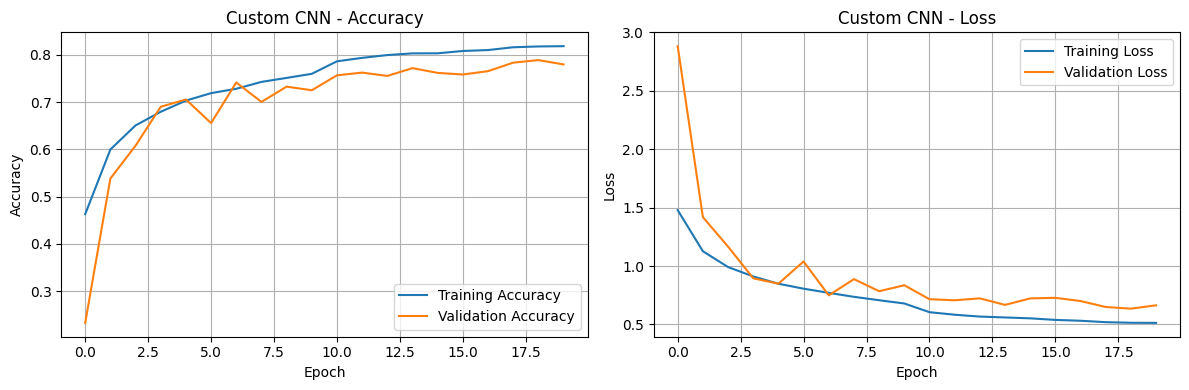

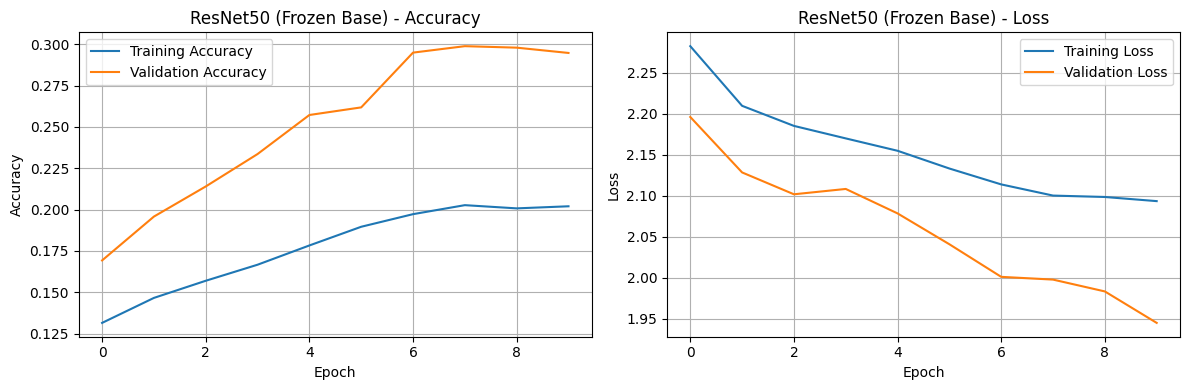

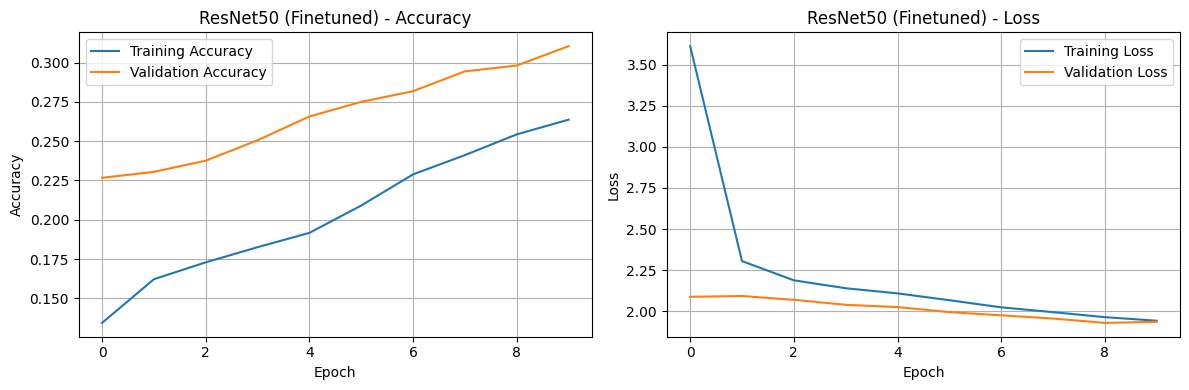

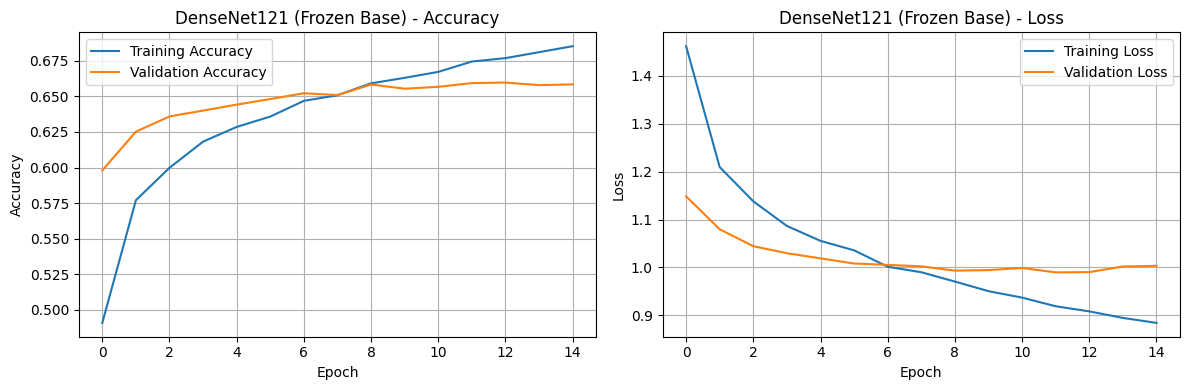

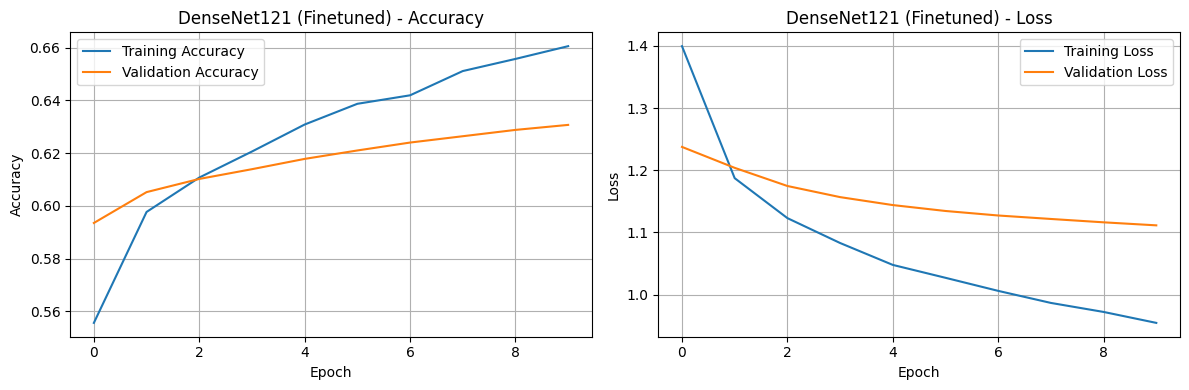

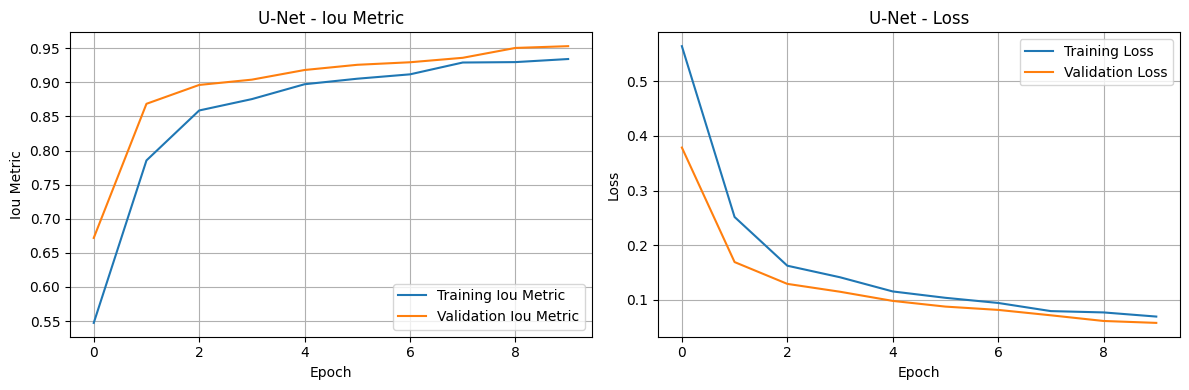

In [8]:
def plot_training_history(history, title):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    # Determine the metric name based on the history keys
    metric_name = 'accuracy' if 'accuracy' in history.history else 'iou_metric'

    ax1.plot(history.history[metric_name], label=f'Training {metric_name.replace("_", " ").title()}')
    if f'val_{metric_name}' in history.history:
        ax1.plot(history.history[f'val_{metric_name}'], label=f'Validation {metric_name.replace("_", " ").title()}')
    ax1.set_title(f'{title} - {metric_name.replace("_", " ").title()}')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel(metric_name.replace("_", " ").title())
    ax1.legend()
    ax1.grid(True)

    ax2.plot(history.history['loss'], label='Training Loss')
    ax2.plot(history.history['val_loss'], label='Validation Loss')
    ax2.set_title(f'{title} - Loss')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend()
    ax2.grid(True)
    plt.tight_layout()
    plt.show()

# Example: plot_training_history(history_custom, 'Custom CNN')
# Fill the table with your model's results after running all models

data = {
    'Model': ['Custom CNN', 'ResNet50', 'DenseNet121', 'U-Net'],
    'Task': ['Classification', 'Classification', 'Classification', 'Segmentation'],
    'Params': [f"{custom_cnn.count_params():,}", f"{resnet50_model.count_params():,}", f"{densenet_model.count_params():,}", f"{unet_model.count_params():,}"],
    'Train Time (s)': [f"{custom_train_time:.2f}", f"{resnet50_train_time:.2f}", f"{densenet_train_time:.2f}", f"{unet_train_time:.2f}"],
    'Accuracy/Metric': [f"{custom_accuracy:.4f}", f"{resnet50_accuracy:.4f}", f"{densenet_accuracy:.4f}", f"{unet_iou:.4f} (IoU)"],
    'Pros': [
        'Fast training, interpretable',
        'Pre-trained features, high accuracy',
        'Efficient feature reuse, good for small datasets',
        'Skip connections, good for segmentation'
    ],
    'Cons': [
        'Limited capacity, may underfit',
        'Large model, computationally expensive',
        'Can be slower than ResNet',
        'Complex architecture, needs paired data'
    ]
}
comparison_df = pd.DataFrame(data)
print(comparison_df)

# Plot training history for each model
plot_training_history(history_custom, 'Custom CNN')
plot_training_history(history_resnet_frozen, 'ResNet50 (Frozen Base)')
plot_training_history(history_resnet_finetuned, 'ResNet50 (Finetuned)')
plot_training_history(history_densenet, 'DenseNet121 (Frozen Base)')
plot_training_history(history_densenet_finetuned, 'DenseNet121 (Finetuned)')
plot_training_history(history_unet, 'U-Net')